Author(s) : Daniel R., Tarry, Laura Gómez Navarro, Elisabet Verger-Miralles

Objective: Describe xxx

Created on: October 2023

Last updated on:


In [1]:
import time

print(time.ctime(time.time()))

Wed Oct 25 18:57:14 2023


In [2]:
# version_information

In [3]:
import numpy as np
import xarray as xr # version 0.20.1 necesarry, 0.16 gives error when calculating u_for
import matplotlib.pyplot as plt
import scipy.signal as signal

from read_data_tools_xr import latlon2uv_dir

In [4]:
print(xr.__version__)

2023.6.0


# Parameters:

In [71]:
url_drifter = 'drifter_carthe011-ime_carthe006/L0/2023/dep0001_drifter-carthe011_ime-carthe006_L0_2023-04-27.nc?'
drifter_type = 'C' # C: CARTHE ; H: Hereon ; S: SVP-B 
diff_time_thres = 3600 # [s] 1h # Will be different for SVP, higher as time res. is 1hr

temp_res = 600. # Specifying seconds 
# Step depending on drifter (CARTHE and HEREON 600s (10 mins (we choose the highest time resolution)) 
# and SVP-B (1h))

# n_window = 12 # we leave like this for now

# CARTHE example

# 1. Loading the data:

In [6]:
# Main root
url_root = "http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/"

In [7]:
# parameters of the thredd file

if drifter_type == 'C':
    url_vars = "trajectory,time[0:1:-1],DEPTH,LAT[0:1:-1],LON[0:1:-1],BAT_STATUS[0:1:-1]"
else:
    print('Hereon is the same, add option, SVP missing temp , press , BAT_status different')
    fsdfs

In [8]:
url = url_root + url_drifter + url_vars
 
print(url)

http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe011-ime_carthe006/L0/2023/dep0001_drifter-carthe011_ime-carthe006_L0_2023-04-27.nc?trajectory,time[0:1:-1],DEPTH,LAT[0:1:-1],LON[0:1:-1],BAT_STATUS[0:1:-1]


In [9]:
# Load file
ds = xr.open_dataset(url)


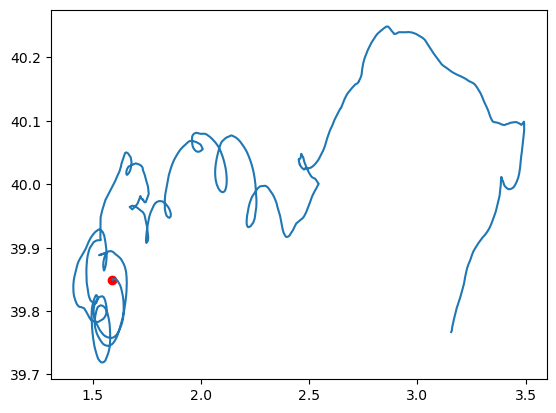

In [10]:
plt.plot(ds.LON, ds.LAT)
plt.scatter(ds.LON[0], ds.LAT[0], c='r')

# 2. Processing:

In [11]:
# Checking time interval:

print(ds.time[0].data)
print(ds.time[1].data)

# --> Should be: 
# 10 mins freq. for CARTHE
# 5 mins HEREON
# 1h SVP-B

2023-04-27T22:33:54.000000000
2023-04-27T22:43:26.000000000


## 2.1. Identifying large time gaps (to kill drifter traj trash)

In [12]:
diff_time_thres = 3600 # [s] 1h

In [13]:
dt_drif = ds.time.diff("time").dt.seconds

In [14]:
# just using np.where, find cleaner method with array to find indices:

In [15]:
inds_trash = np.where(dt_drif > diff_time_thres)
inds_trash

(array([ 865,  867,  871,  877,  886,  890,  894,  896,  897,  898,  899,
         900,  901,  903,  904,  905,  910,  914,  915,  925,  934,  941,
         954,  960,  972,  985,  986,  987,  989,  992,  998, 1002, 1007,
        1009, 1024, 1025, 1036, 1059, 1136, 1285, 1298, 1302, 1305, 1343,
        1344, 1350, 1357, 1703, 1704, 1706, 1712, 1716, 1717, 1820, 1823,
        1824, 1825, 1879, 1881, 1884, 1886, 1912, 1957, 1965, 1966, 1972]),)

In [16]:
inds_trash[0][0]

865

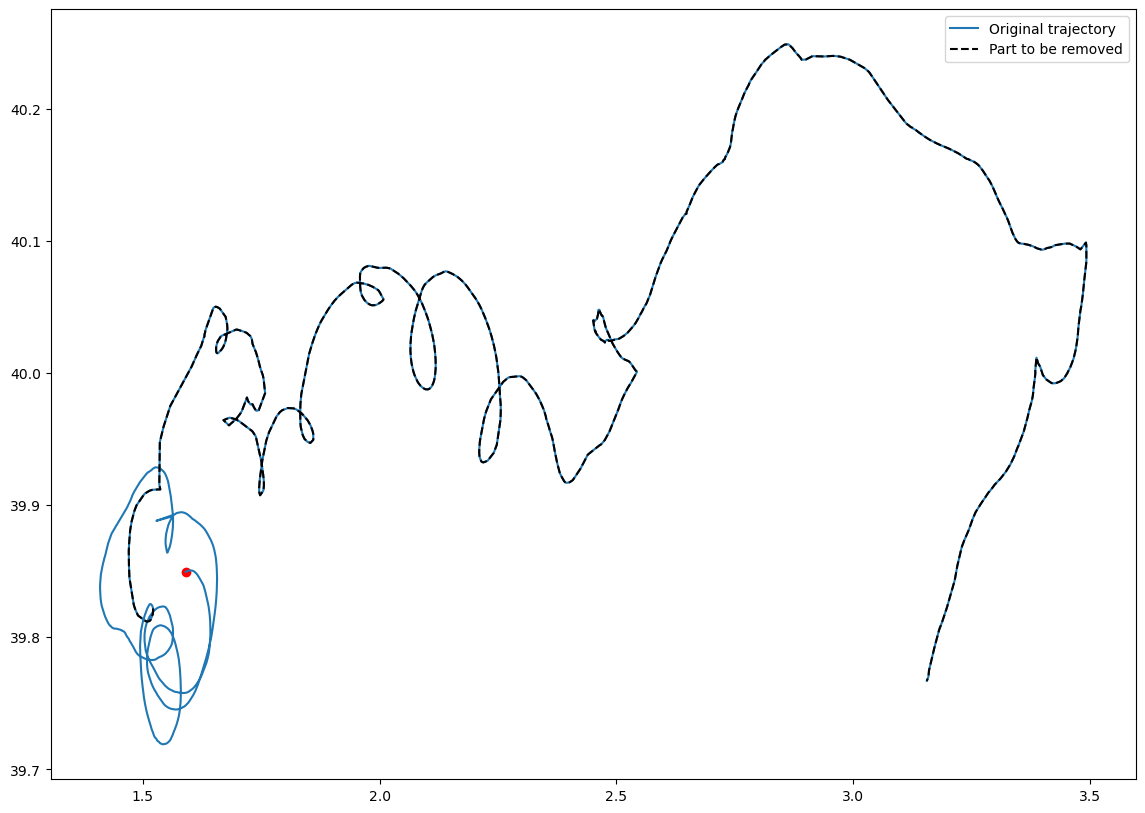

In [17]:
plt.figure(figsize=(14,10))
plt.plot(ds.LON, ds.LAT, label='Original trajectory')
plt.scatter(ds.LON[0], ds.LAT[0], c='r')
plt.plot(ds.LON[inds_trash[0][0]::], ds.LAT[inds_trash[0][0]::], '--k', label='Part to be removed')
plt.legend()

(39.7, 40.0)

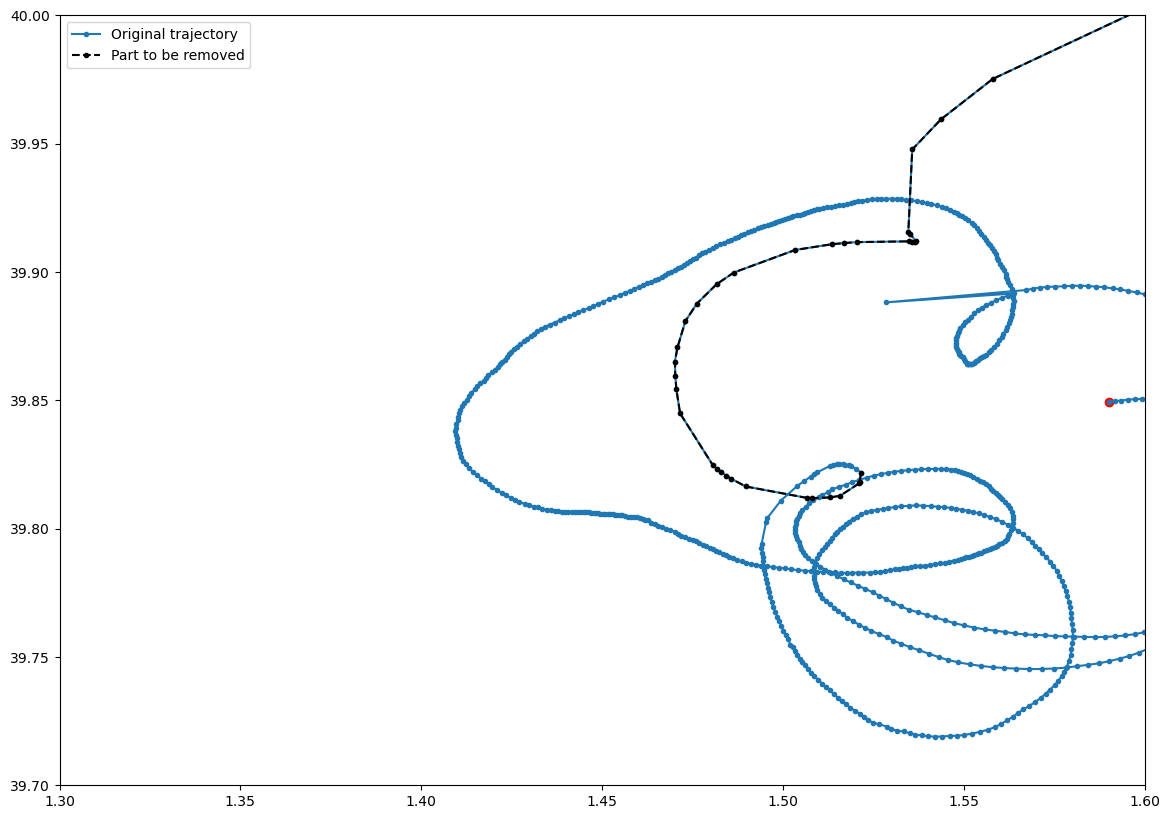

In [18]:
plt.figure(figsize=(14,10))
plt.plot(ds.LON, ds.LAT, '.-', label='Original trajectory')
plt.scatter(ds.LON[0], ds.LAT[0], c='r')
plt.plot(ds.LON[inds_trash[0][0]::], ds.LAT[inds_trash[0][0]::], '.--k', label='Part to be removed')
plt.legend()
plt.xlim([1.3,1.6])
plt.ylim([39.7,40.])

# --> in this case, 1 hour too conservative, let's try 2 hours:

In [19]:
diff_time_thres = 3600 * 2 # [s] 1h

In [20]:
dt_drif = ds.time.diff("time").dt.seconds

In [21]:
# just using np.where, find cleaner method with array to find indices:

In [22]:
inds_trash = np.where(dt_drif > diff_time_thres)[0]
inds_trash

array([ 890,  896,  898,  899,  903,  910,  914,  934,  954,  972,  985,
        989, 1716, 1717, 1825, 1886, 1965])

In [23]:
inds_trash[0]

890

# --> we DONT keep all!

In [24]:
# ds.time[inds_trash[0][0]+2]

In [25]:
# array.size > 0
inds_trash.size

17

In [26]:
if inds_trash.size > 0: 
    ds01 = ds.where(ds.time<ds.time[inds_trash[0]+2], drop=True) # to improve 
    # + 2 because +1 of normal python indices , and 1 more because based on the indices of the array of time differences
elif inds_trash.size == 0:
    ds01 = ds.copy()
else:
    print('Problem')
    fsdgsdfg

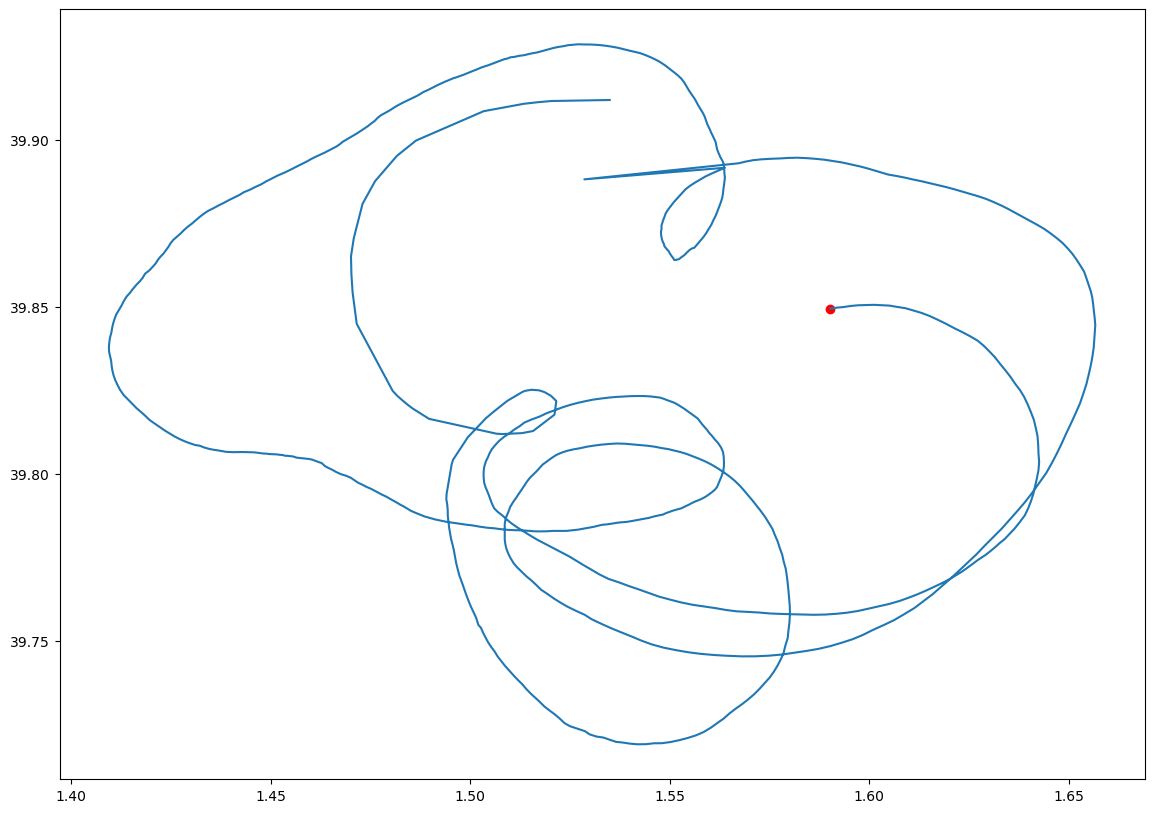

In [27]:
plt.figure(figsize=(14,10))
plt.plot(ds01.LON, ds01.LAT)
plt.scatter(ds01.LON[0], ds01.LAT[0], c='r')

# --> very short trajectory, very big jump seen above, could be that drogue lost, how to detect? Check with Brest people

## 2.2. Resampling to regular 10 mins. intervals:
(constant 10 mins and "o'clock" times)

### 2.2.1. Making lon and lat variables instead of coordinates
If we do not do this step when resampling we loose lon and lat in the dataset.  To keep in mind that this may give problems in further calculations with xarray that might need lon and lat as coords.

In [29]:
ds01 = ds01.reset_coords("LON")
ds01 = ds01.reset_coords("LAT")

In [30]:
ds01

<xarray.Dataset>
Dimensions:     (time: 892)
Coordinates:
  * time        (time) datetime64[ns] 2023-04-27T22:33:54 ... 2023-05-04T21:5...
Data variables:
    trajectory  (time) object b'drifter-carthe011_ime-carthe006_L0' ... b'dri...
    DEPTH       (time) float64 0.6 0.6 0.6 0.6 0.6 0.6 ... 0.6 0.6 0.6 0.6 0.6
    BAT_STATUS  (time) float64 1.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    LAT         (time) float64 39.85 39.85 39.85 39.85 ... 39.91 39.91 39.91
    LON         (time) float64 1.59 1.592 1.594 1.595 ... 1.513 1.517 1.52 1.535
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE006 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE006 in FaSt-...
    summary:                             Deployment of IME-CARTHE006 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

### 2.2.2. Resampling:

In [31]:
ds02 = ds01.resample(time=f"{int(temp_res)}s").interpolate("linear") # xarray resample works very differently from pandas


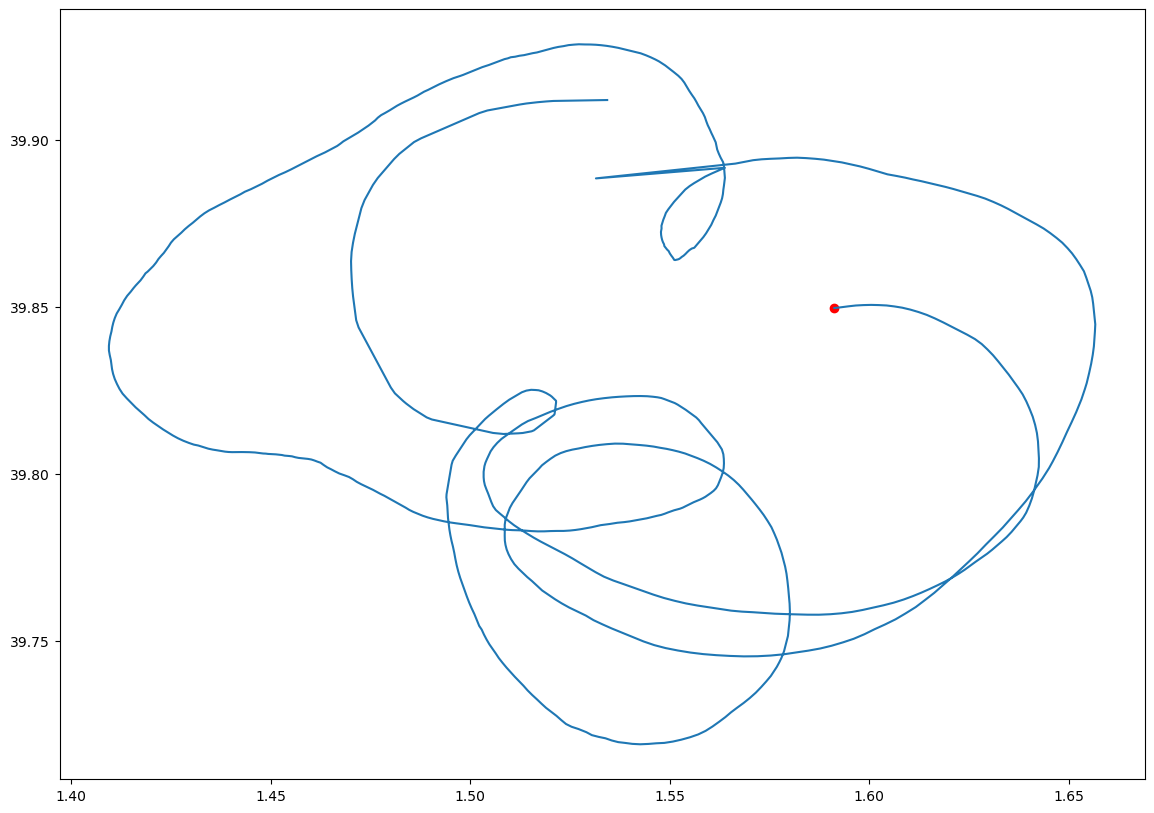

In [32]:
plt.figure(figsize=(14,10))
plt.plot(ds02.LON, ds02.LAT)
# plt.scatter(ds02.LON[0], ds02.LAT[0], c='r') # first point is nan now
plt.scatter(ds02.LON[1], ds02.LAT[1], c='r')

# --> spikes now smaller but still present
# To improve: maybe better to remove spikes with lon and lat (thres 0.02?) before resampling so that spike not spread

## 2.3. Calculate forward and backward velocities

blabla bla boundary conditions, back (t-1) , and forward (vel at t+1) calculated
# --> Dani

In [35]:
ufor, vfor   = latlon2uv_dir(ds02['LAT'], ds02['LON'], temp_res, 'for') # 600 = temporal resolution
uback, vback = latlon2uv_dir(ds02['LON'], ds02['LAT'], temp_res, 'back')

In [36]:
# Add variables to the dataset
ds02 = ds02.assign(U=(ufor+uback)*0.5)
ds02 = ds02.assign(V=(vfor+vback)*0.5)
print(list(ds02.keys()))

['DEPTH', 'BAT_STATUS', 'LAT', 'LON', 'trajectory', 'U', 'V']


In [37]:
ds02.U.values

array([       nan, 0.15778344, 0.17130632, ..., 0.12458422, 0.12027241,
              nan])

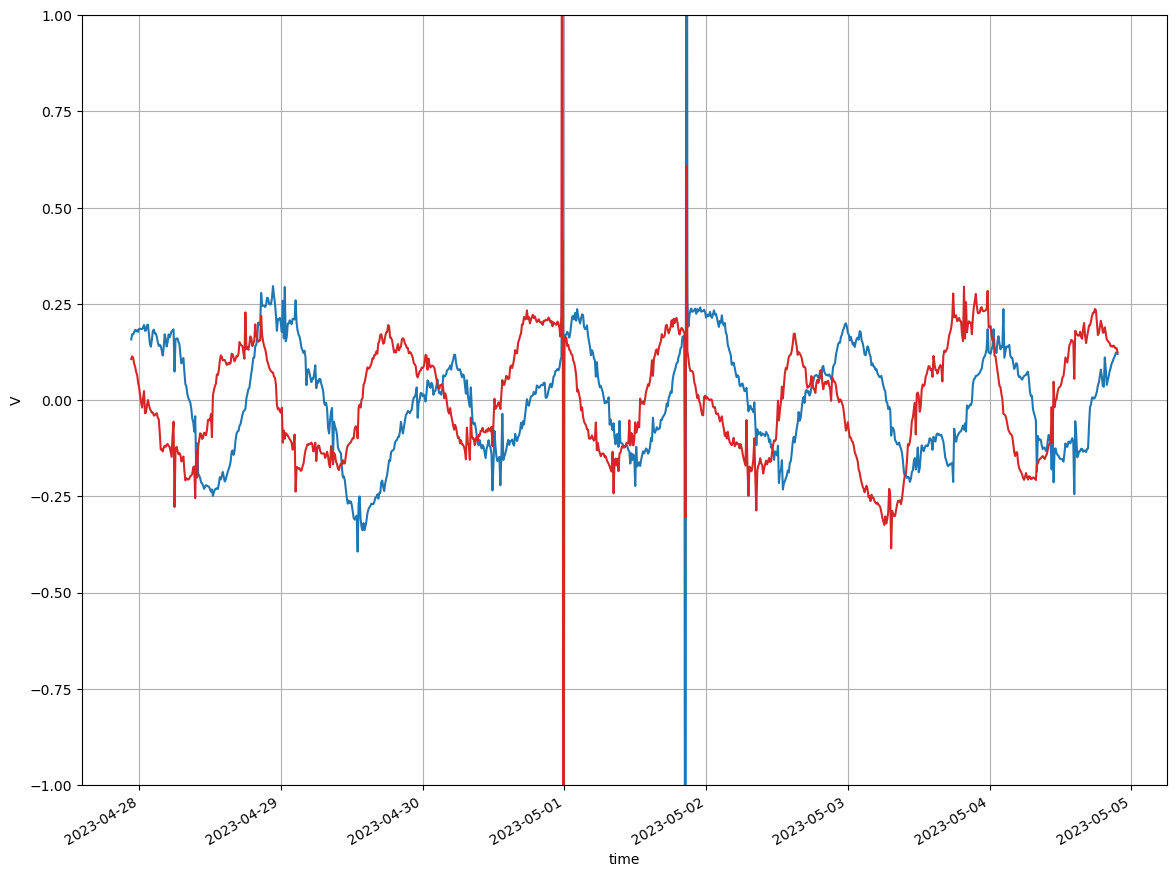

In [38]:
ds02.U.plot(figsize=(14,10))
ds02.V.plot(c='C3')
plt.ylim([-1, 1])
plt.grid()

# --> peaks not in phase, ok?

## 2.4. Spike cleaning:

Cleaning spikes now based on velocity thresholds(absolute velocity (speed))

In [39]:
abs_vel = (ds02.U**2 + ds02.V**2)**0.5

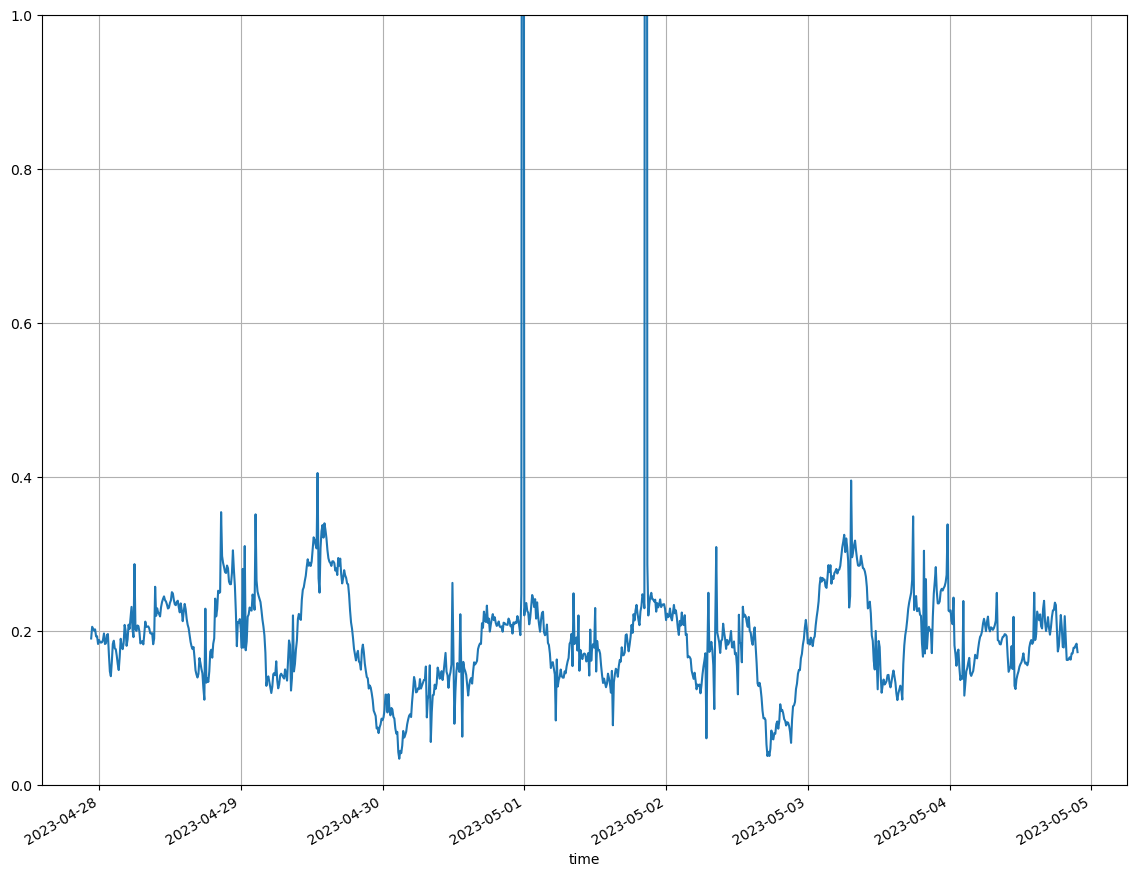

In [40]:
abs_vel.plot(figsize=(14,10))
plt.ylim([0,1])
plt.grid()

Based on above plot we choose 0.8 m/s.

To improve:
- big spike cleaning with lon and lat thres. before resmpling
- do a moving vel. thres.
- would be better to filter spikes on acceleration, but harder then to choose threshold (less intuitive)

In [45]:
vel_thres = 0.8 # m/s 

In [46]:
ds03 = ds02.where(abs_vel < vel_thres)

In [47]:
abs_vel_new = (ds03.U**2 + ds03.V**2)**0.5

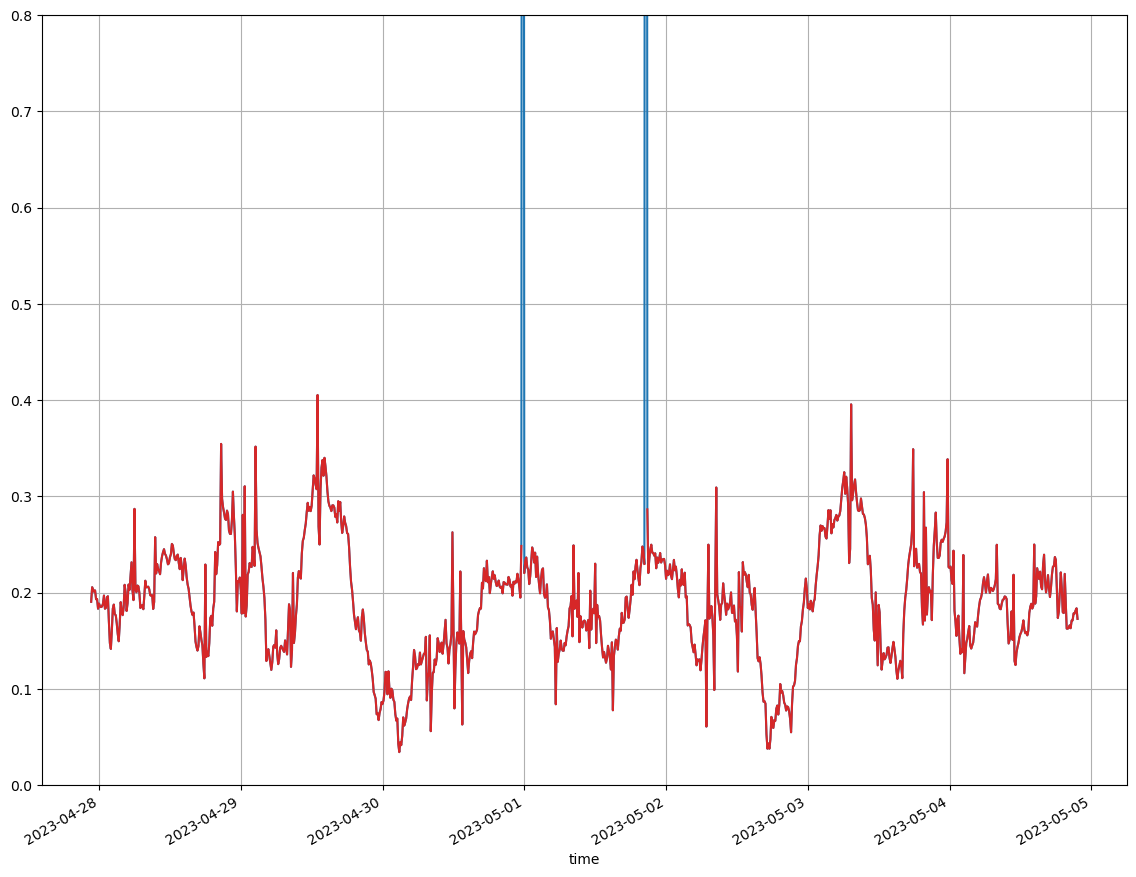

In [48]:
abs_vel.plot(figsize=(14,10))
abs_vel_new.plot(c='C3')
plt.ylim([0,0.8])
plt.grid()

TypeError: No numeric data to plot.

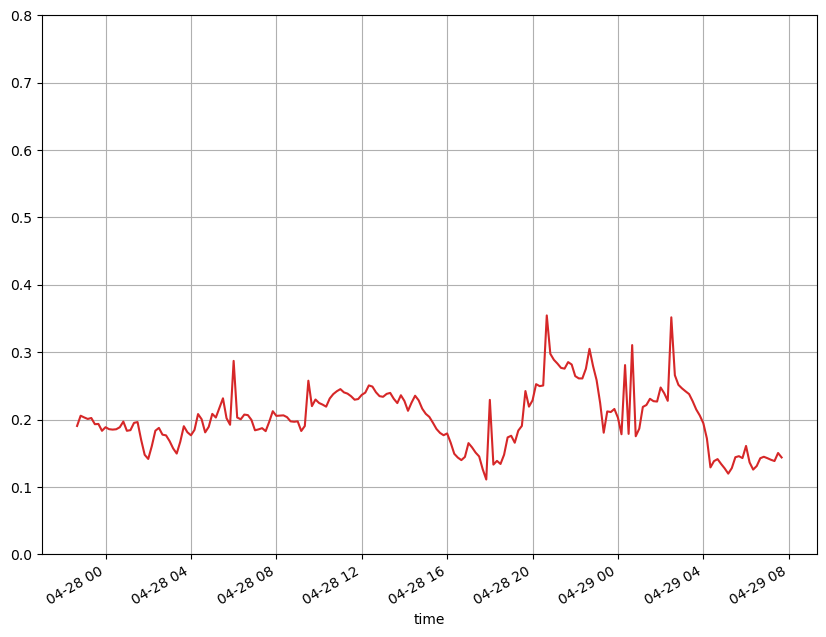

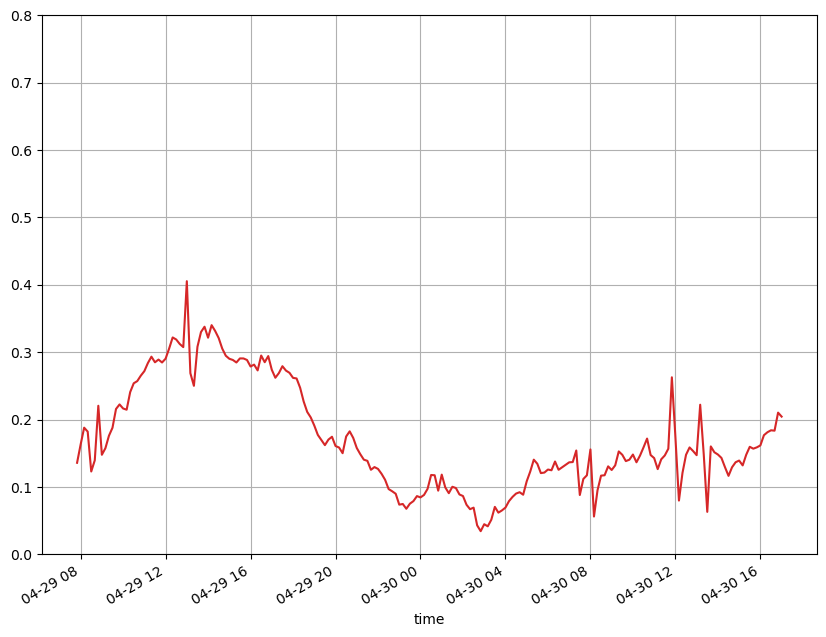

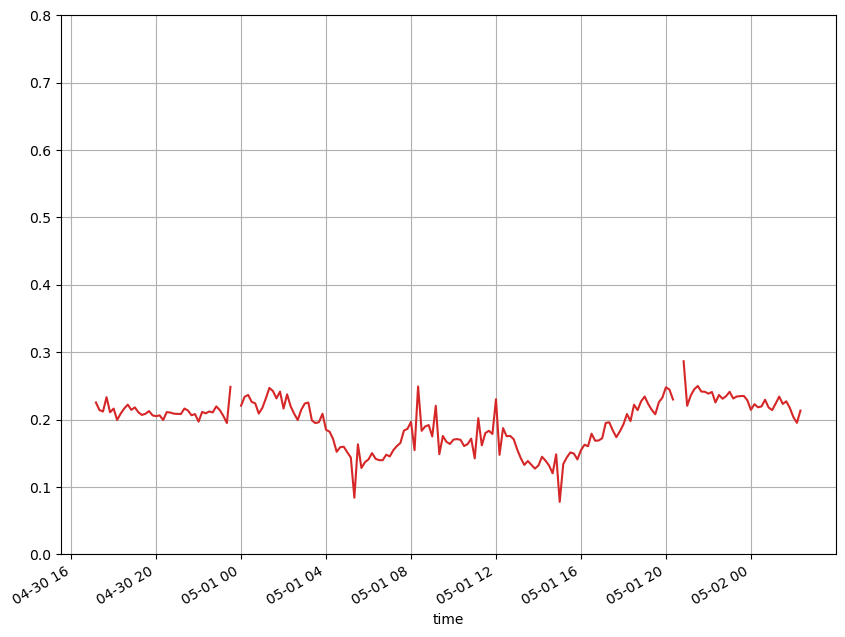

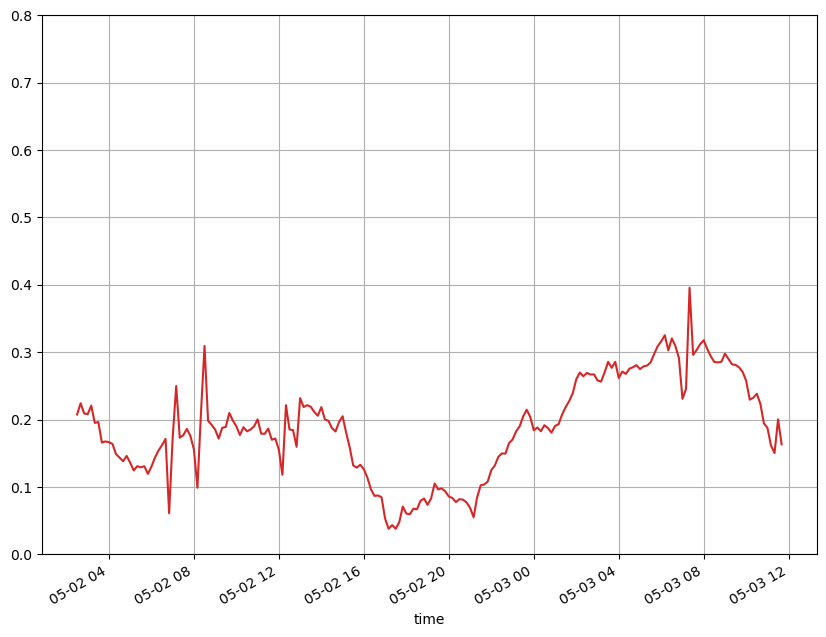

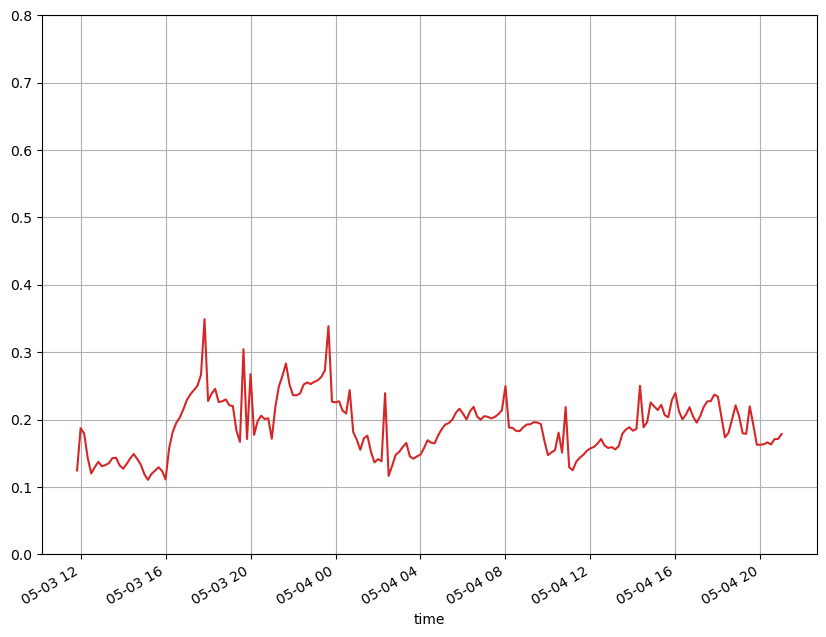

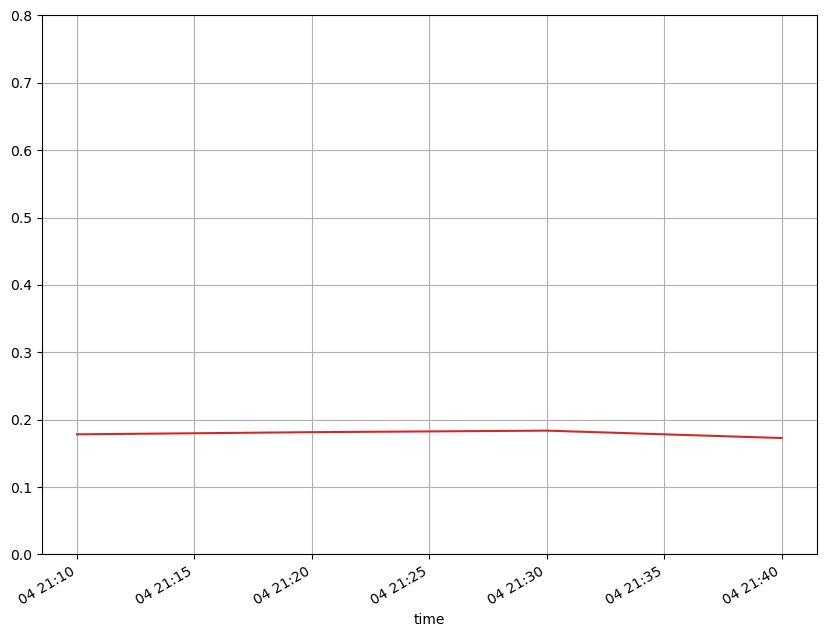

In [49]:
# to visualize data gaps:
for ii in range(0,10):
    abs_vel_new[(ii*200):((ii+1)*200)].plot(figsize=(10,7), c='C3')
    plt.ylim([0,0.8])
    plt.grid()

## 2.5. Smoothing

### 2.5.1. Interpolation
(again to fill in spike gaps, smoothing method applied (for now) next does not fill in the gaps) --> to check

In [50]:
# To apply interpolate, we need to remove the trajectory variable because it is a string not a float (number)
ds03 = ds03.drop_vars("trajectory") # trajectory variable unnecessary, check with Lara --> not better attrubte?

In [51]:
ds04 = ds03.interpolate_na(dim='time', method="pchip") 
# Pchip : cubic with splines interp. (Dani find ref.)

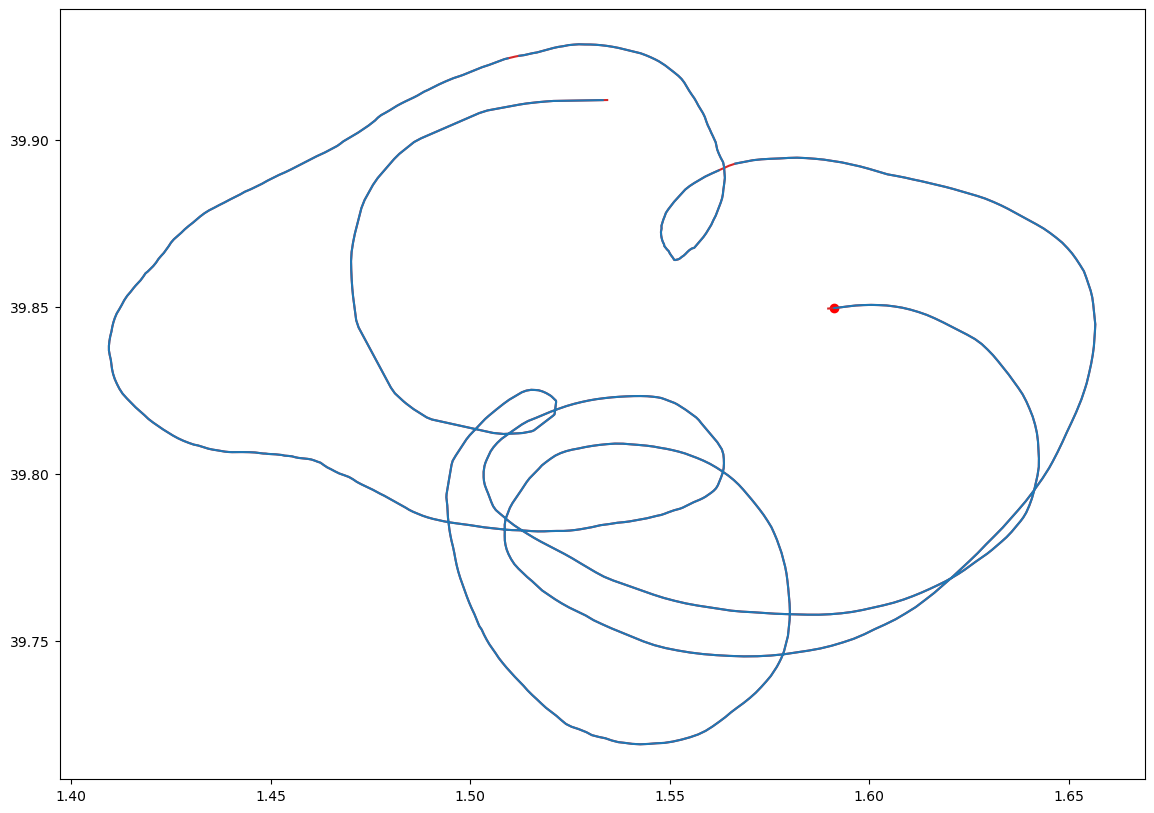

In [52]:
plt.figure(figsize=(14,10))
plt.plot(ds04.LON, ds04.LAT, 'C3')
plt.plot(ds03.LON, ds03.LAT)
plt.scatter(ds04.LON[1], ds04.LAT[1], c='r')

### 2.5.2. Applying smoothing
To remove small scale noise and any remaining spikes.

(we apply window to smooth the data on the lon and lat drifters, to the recalculate vels (could also apply directly on vels... we will see later) )


# --> for now we leave it at n=12 <-> 2h (method to be refined as smoothes too much at peaks, very flat)

https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve.html

# %%%%%%%%%%%
# Testing with abs_vel:

In [53]:
abs_vel_new = (ds04.U**2 + ds04.V**2)**0.5

In [54]:
ii = 3

### Trying different window sizes:
https://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.signal.hann.html 

signal.hamming(n) ; n = number of points. If we want a 30 mins window, n=3.

In [55]:
# Apply the Hamming
variable = abs_vel_new[(ii*200):((ii+1)*200)]

window = signal.windows.hamming(3)
filtered_variable_03 = signal.convolve(variable, window, mode='same') / np.sum(window)
window = signal.windows.hamming(6)
filtered_variable_06 = signal.convolve(variable, window, mode='same') / np.sum(window)
window = signal.windows.hamming(12)
filtered_variable_12 = signal.convolve(variable, window, mode='same') / np.sum(window)


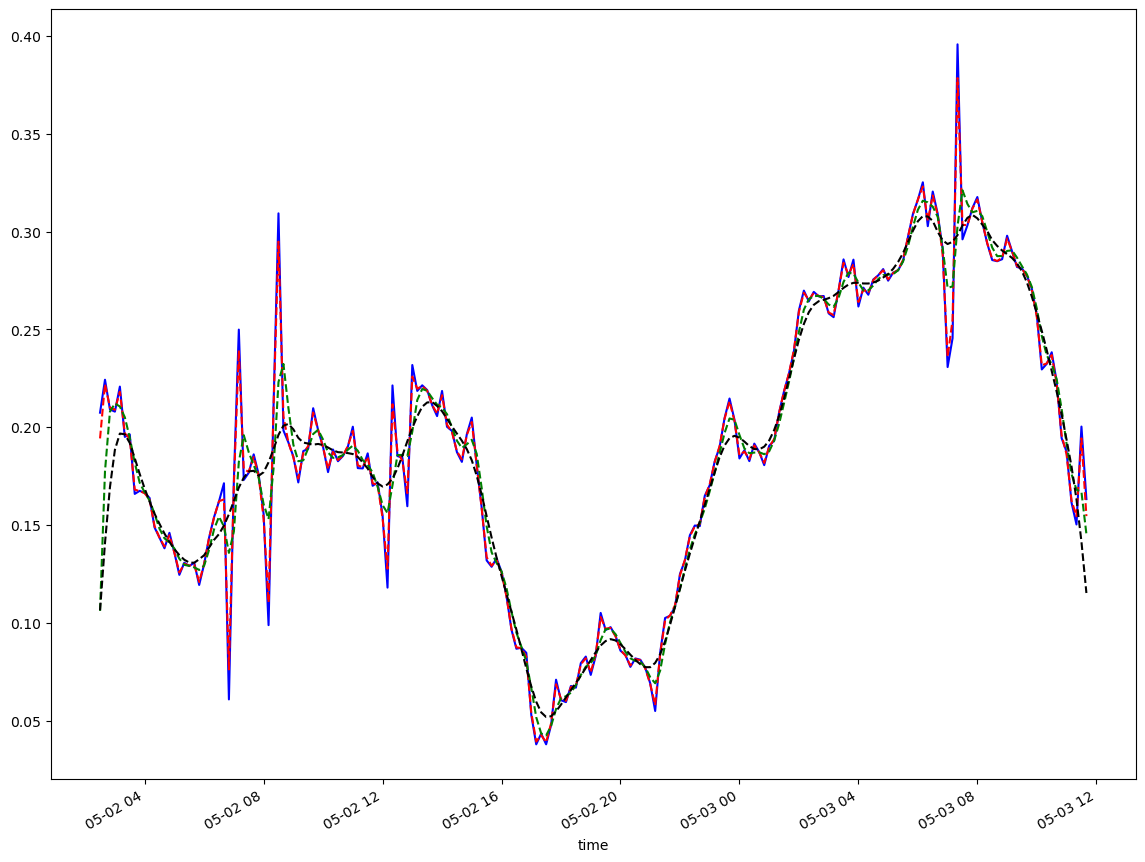

In [56]:
variable.plot(c='b',figsize=(14,10))
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_03, '--r')
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_06, '--g')
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_12, '--k')

# --> need to see how the borders were fixed (Laura check)

# --> 12 looks best (2h window)

## Checking out Hann window: (equivalent to Hanning??)

In [57]:
window = signal.windows.hann(3)
filtered_variable_03_hann = signal.convolve(variable, window, mode='same') / np.sum(window)
window = signal.windows.hann(6)
filtered_variable_06_hann = signal.convolve(variable, window, mode='same') / np.sum(window)
window = signal.windows.hann(12)
filtered_variable_12_hann = signal.convolve(variable, window, mode='same') / np.sum(window)

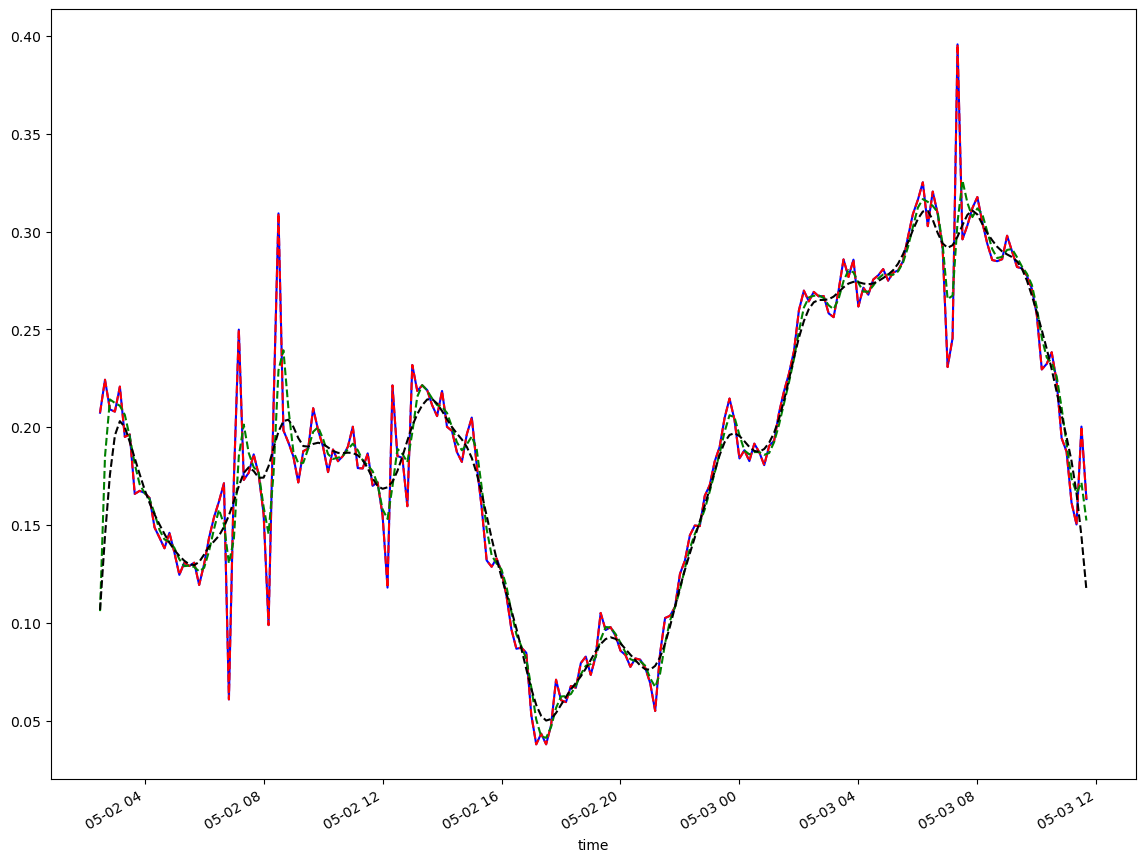

In [58]:
variable.plot(c='b',figsize=(14,10))
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_03_hann, '--r')
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_06_hann, '--g')
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_12_hann, '--k')

# --> difference?

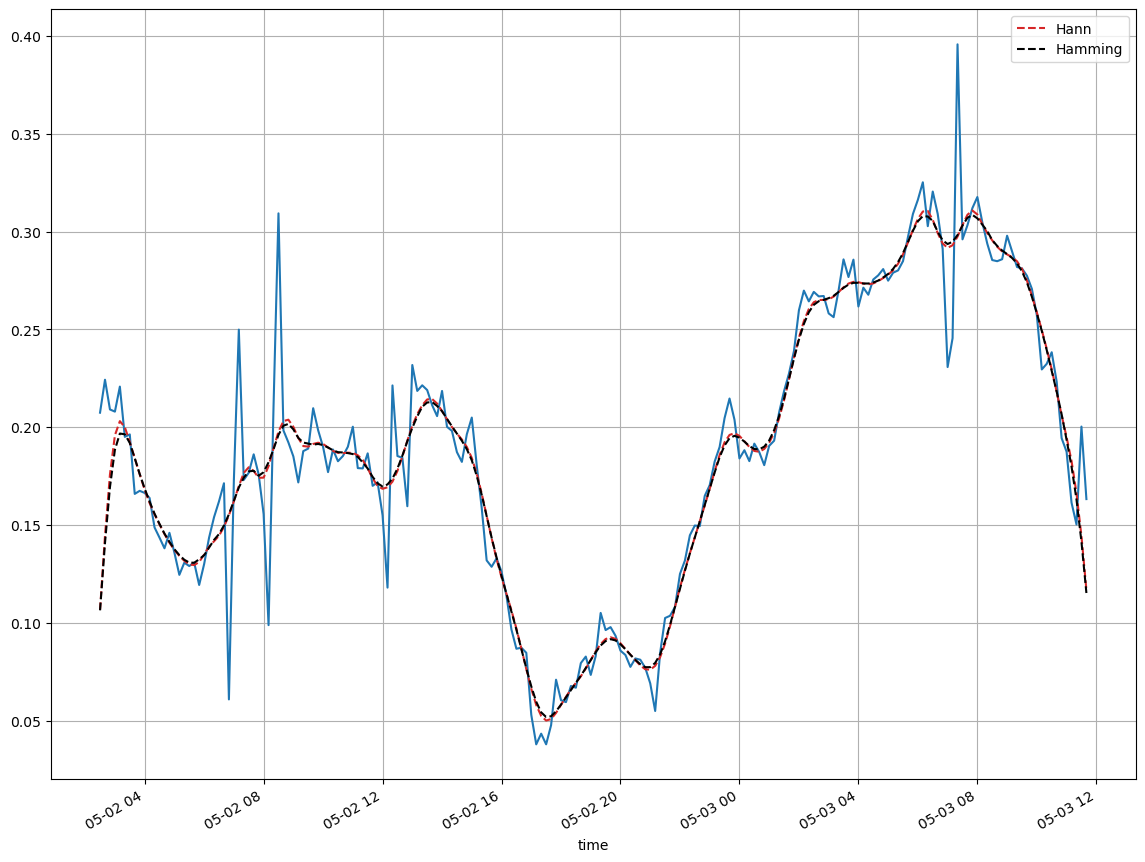

In [59]:
variable.plot(c='C0',figsize=(14,10))
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_12_hann, '--', c='C3', label='Hann')
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_12, '--k', label='Hamming')
plt.grid()
plt.legend()

# --> not much differences, only on peaks

## Checking all sections:

TypeError: No numeric data to plot.

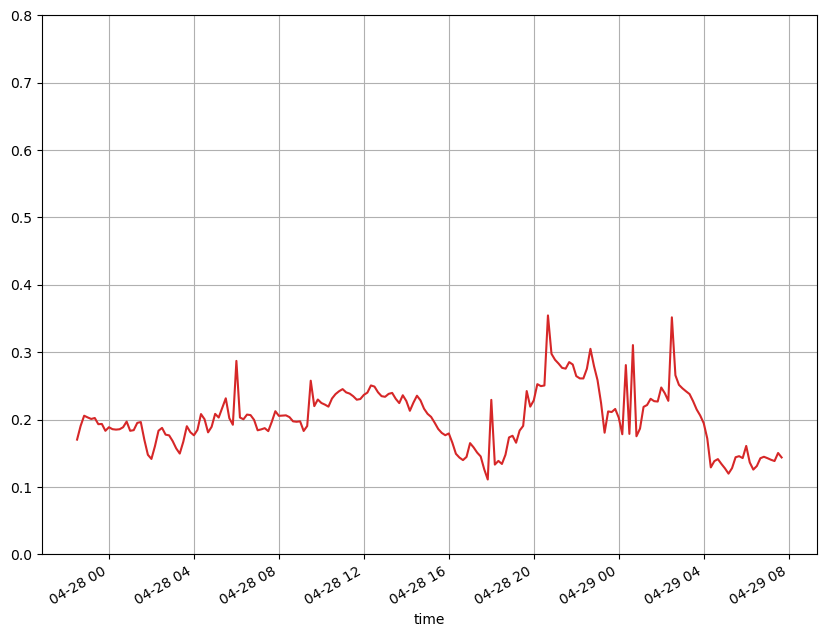

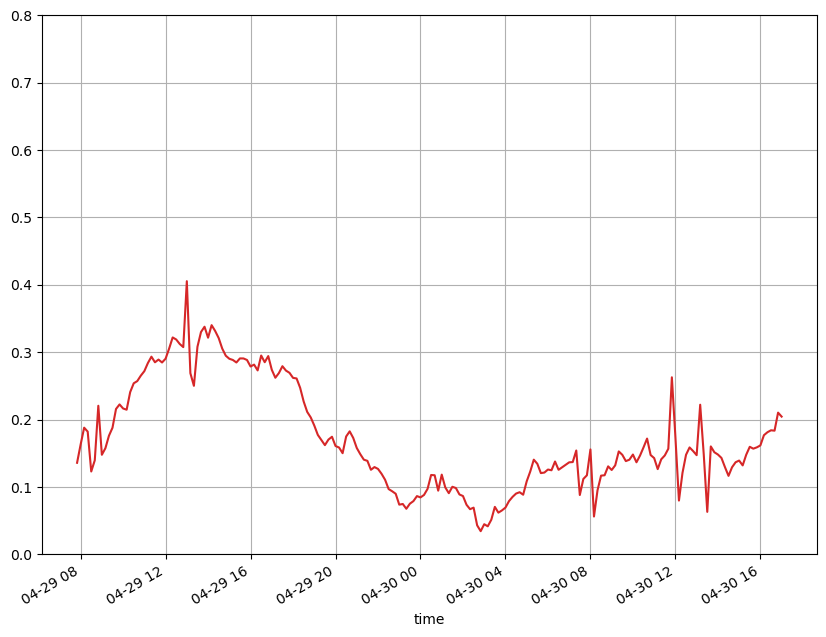

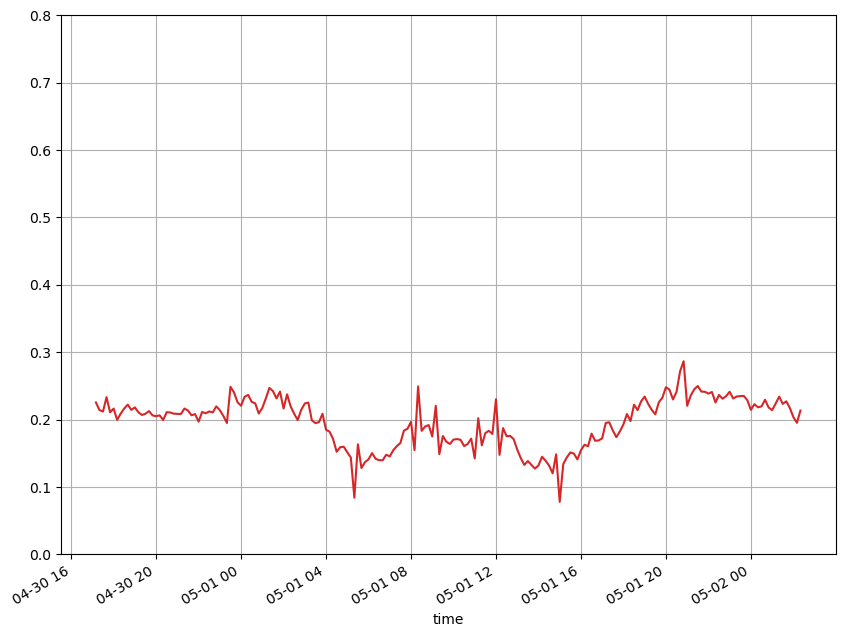

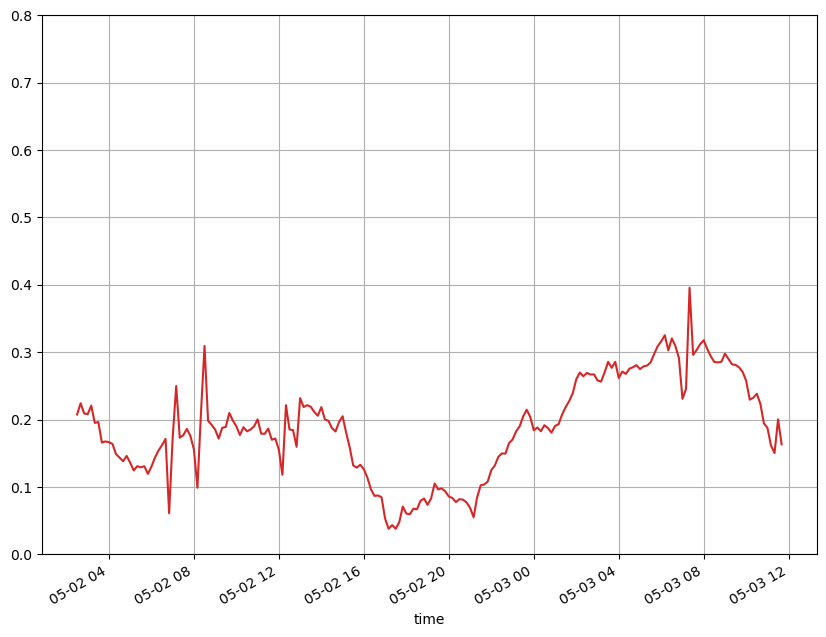

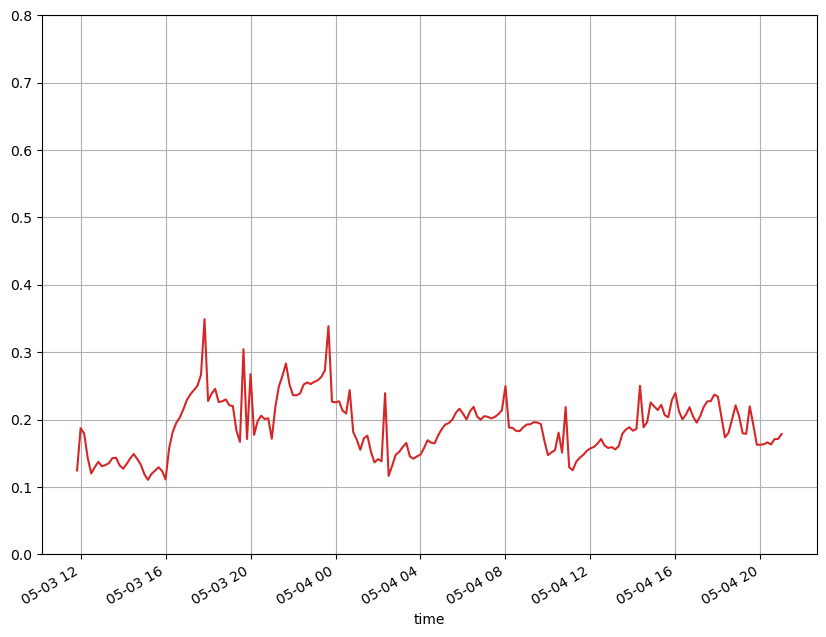

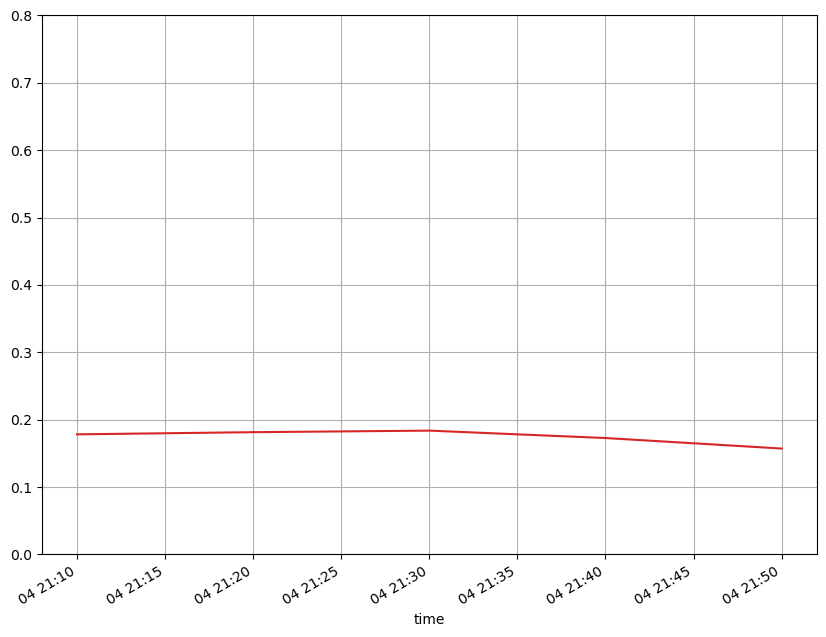

In [60]:
# to visualize data gaps:
for ii in range(0,10):
    abs_vel_new[(ii*200):((ii+1)*200)].plot(figsize=(10,7), c='C3')
    plt.ylim([0,0.8])
    plt.grid()

In [61]:
# Apply the Hamming
variable = abs_vel_new

window = signal.windows.hamming(3)
filtered_variable_03 = signal.convolve(variable, window, mode='same') / np.sum(window)
window = signal.windows.hamming(6)
filtered_variable_06 = signal.convolve(variable, window, mode='same') / np.sum(window)
window = signal.windows.hamming(12)
filtered_variable_12 = signal.convolve(variable, window, mode='same') / np.sum(window)


TypeError: No numeric data to plot.

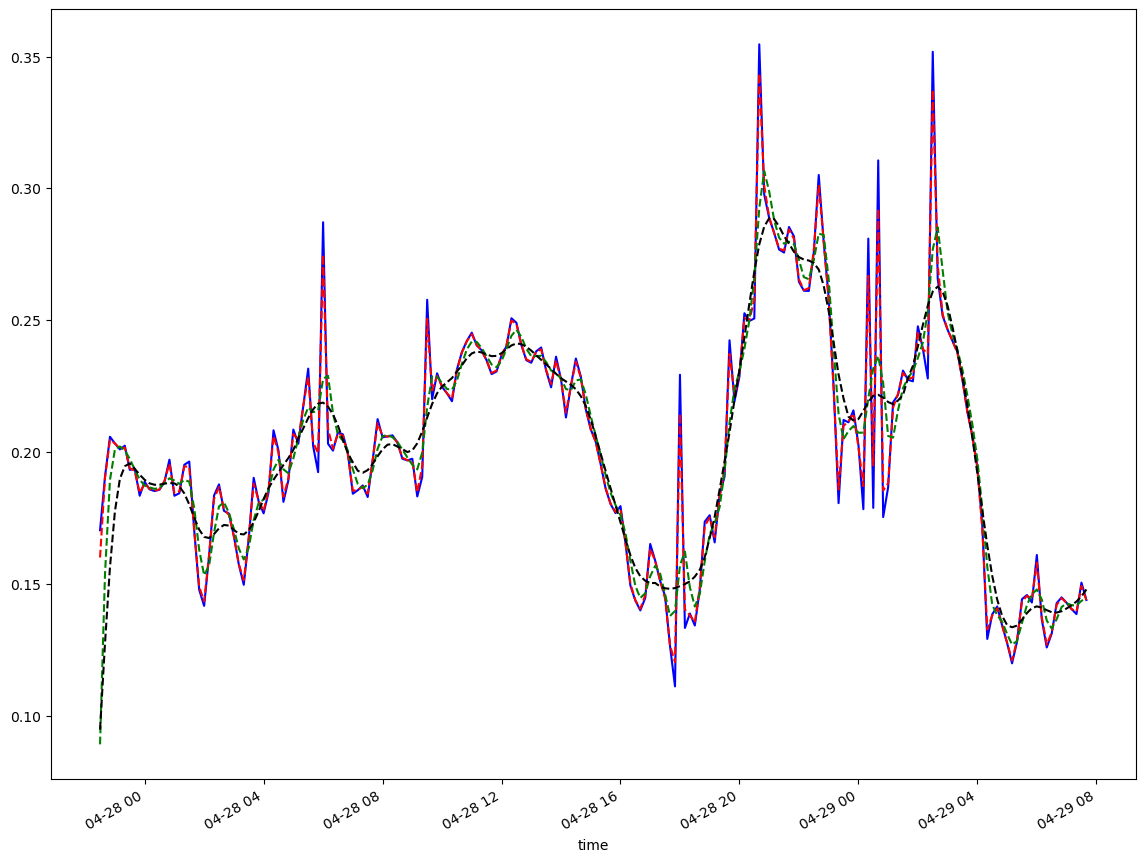

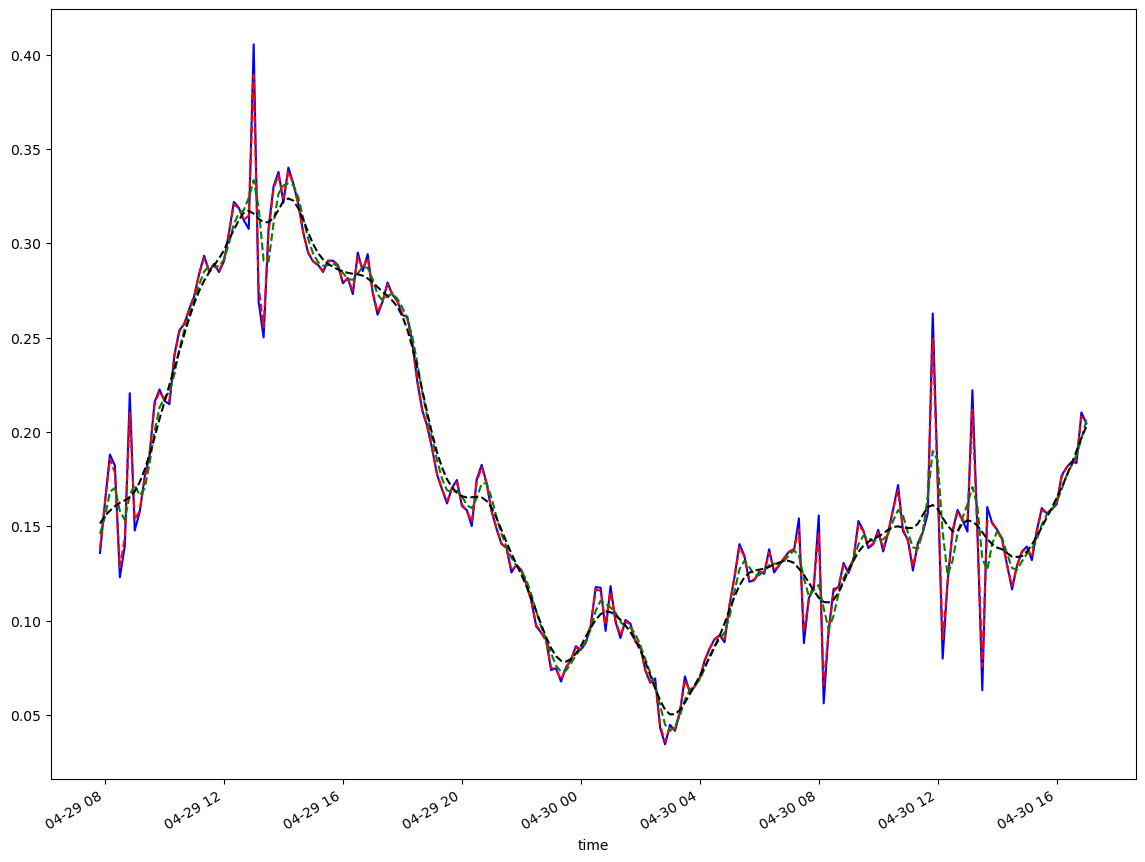

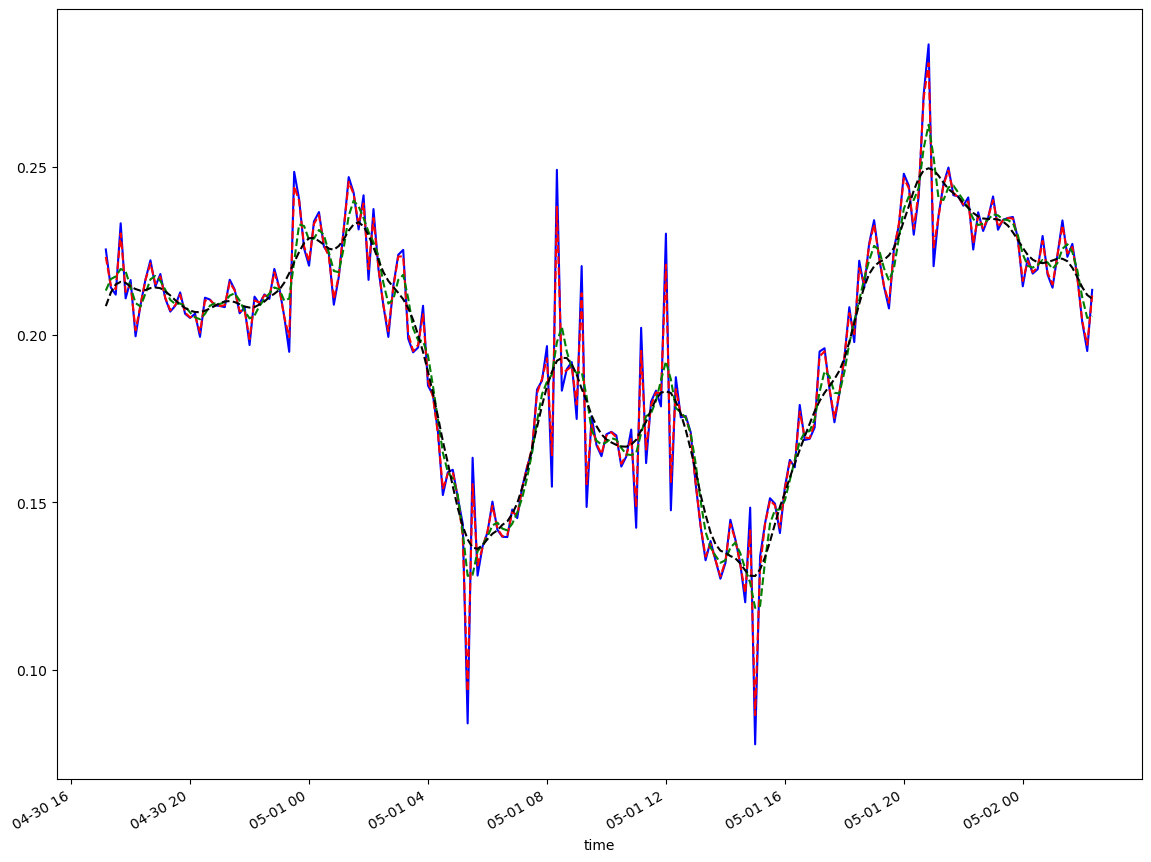

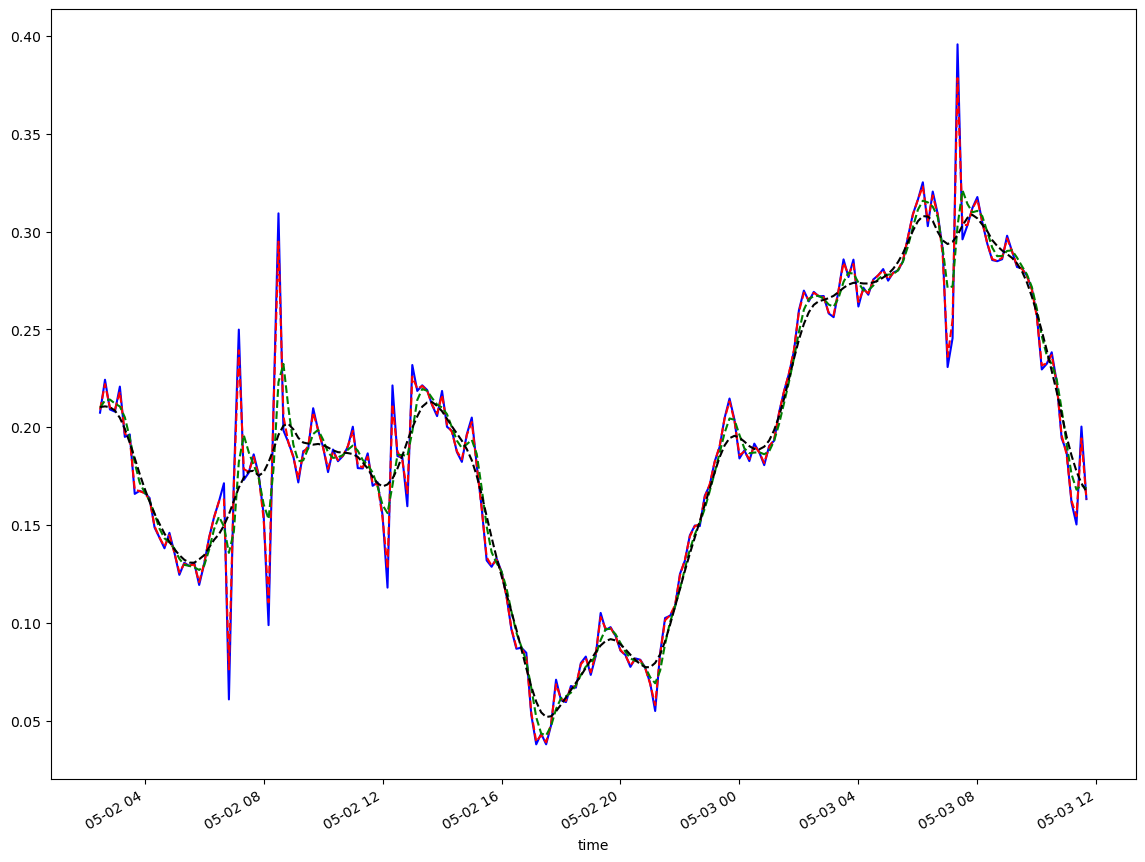

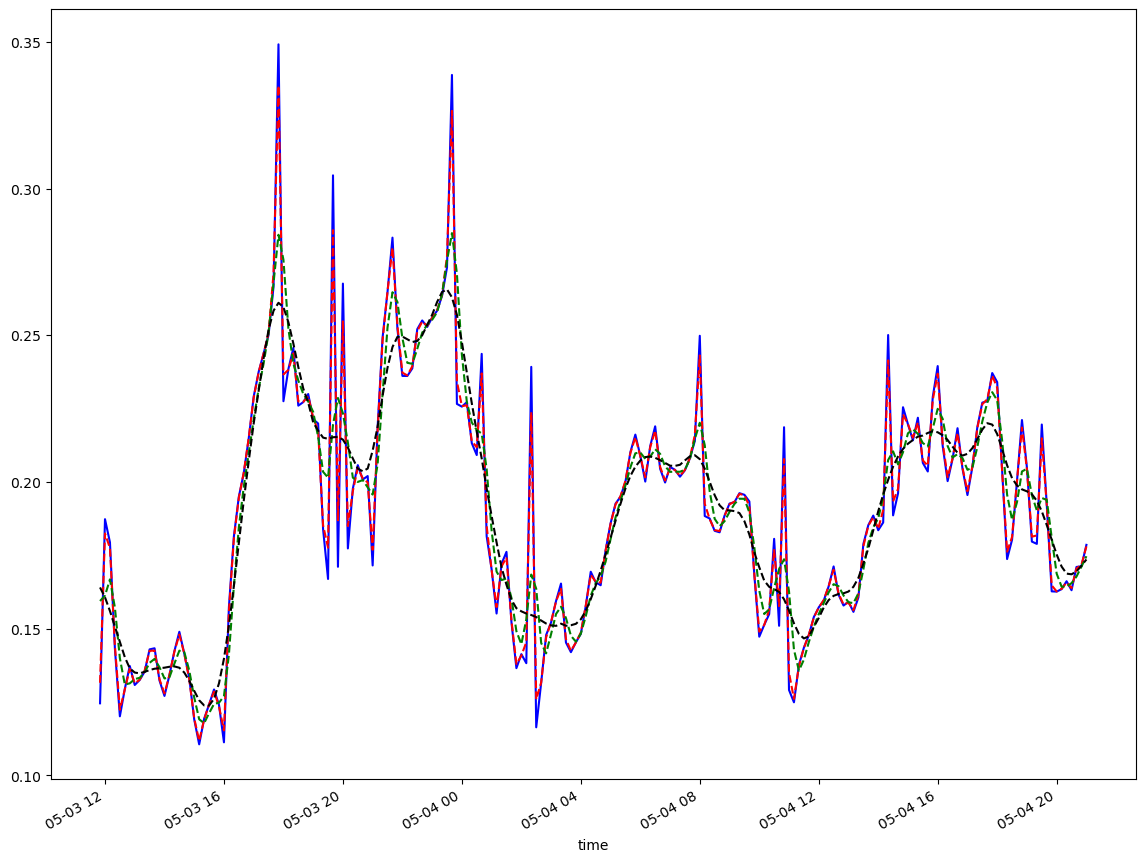

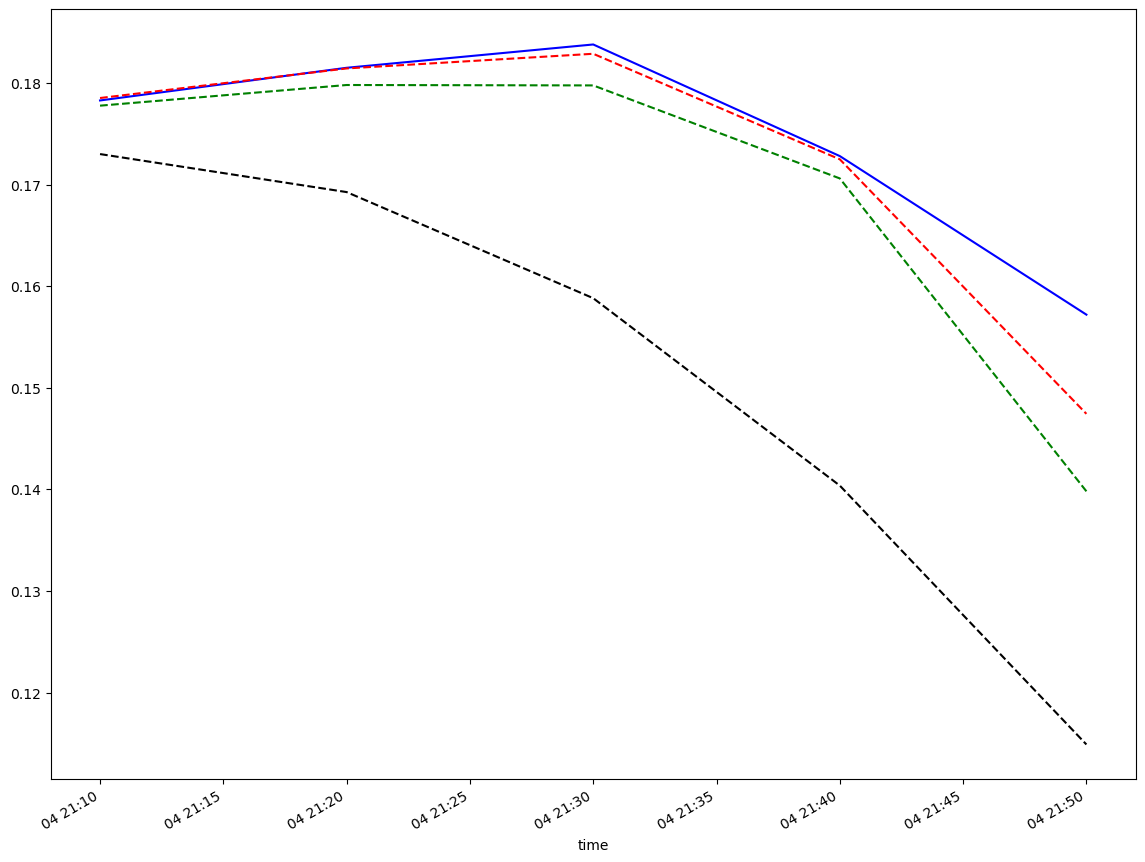

In [62]:
# to visualize data gaps:
for ii in range(0,10):
    variable[(ii*200):((ii+1)*200)].plot(c='b',figsize=(14,10))
    plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_03[(ii*200):((ii+1)*200)], '--r')
    plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_06[(ii*200):((ii+1)*200)], '--g')
    plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_12[(ii*200):((ii+1)*200)], '--k')

# --> increase of spikes after the 1 hour gap??

# %%%%%%%%%%%

#### Smoothing on lon and lat:

In [63]:
ds05 = ds04.copy()

In [64]:
ds05

<xarray.Dataset>
Dimensions:     (time: 1005)
Coordinates:
  * time        (time) datetime64[ns] 2023-04-27T22:30:00 ... 2023-05-04T21:5...
Data variables:
    DEPTH       (time) float64 0.6 0.6 0.6 0.6 0.6 0.6 ... 0.6 0.6 0.6 0.6 0.6
    BAT_STATUS  (time) float64 1.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    LAT         (time) float64 39.85 39.85 39.85 39.85 ... 39.91 39.91 39.91
    LON         (time) float64 1.59 1.591 1.593 1.595 ... 1.532 1.533 1.534
    U           (time) float64 0.1441 0.1578 0.1713 ... 0.1246 0.1203 0.1104
    V           (time) float64 0.09074 0.1069 0.114 ... 0.1351 0.1241 0.1119
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE006 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE006 in FaSt-...
    summary:                             Deployment of IME-CARTHE006 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

In [65]:
# ds05["LON"] = ds04.LON.rolling(time=12, center=True).median()
# ds05["LAT"] = ds04.LAT.rolling(time=12, center=True).median()

window = signal.windows.hamming(12) # 2 hours (12 points) 

ds05["LON"][:] = signal.convolve(ds04.LON.values, window, mode='same') / np.sum(window)
ds05["LAT"][:] = signal.convolve(ds04.LAT, window, mode='same') / np.sum(window)


In [66]:
ds05

<xarray.Dataset>
Dimensions:     (time: 1005)
Coordinates:
  * time        (time) datetime64[ns] 2023-04-27T22:30:00 ... 2023-05-04T21:5...
Data variables:
    DEPTH       (time) float64 0.6 0.6 0.6 0.6 0.6 0.6 ... 0.6 0.6 0.6 0.6 0.6
    BAT_STATUS  (time) float64 1.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    LAT         (time) float64 19.92 26.42 31.99 36.0 ... 36.05 32.04 26.46
    LON         (time) float64 0.796 1.056 1.279 1.441 ... 1.383 1.23 1.016
    U           (time) float64 0.1441 0.1578 0.1713 ... 0.1246 0.1203 0.1104
    V           (time) float64 0.09074 0.1069 0.114 ... 0.1351 0.1241 0.1119
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE006 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE006 in FaSt-...
    summary:                             Deployment of IME-CARTHE006 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

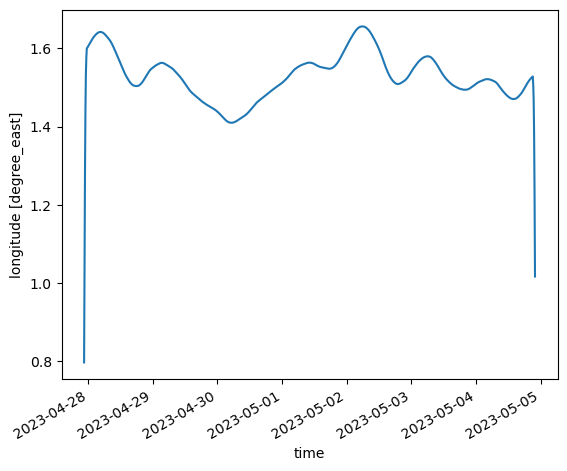

In [67]:
ds05.LON.plot()

# --> weird dips in LON at extremes --> to be fixed (mentioned above)

# Recalculate U and V:

In [68]:
ufor, vfor   = latlon2uv_dir(ds05['LAT'], ds05['LON'], temp_res, 'for') # 600 = temporal resolution
uback, vback = latlon2uv_dir(ds05['LON'], ds05['LAT'], temp_res, 'back')

In [69]:
# Add variables to the dataset
ds05 = ds05.assign(U=(ufor+uback)*0.5)
ds05 = ds05.assign(V=(vfor+vback)*0.5)
print(list(ds05.keys()))

['DEPTH', 'BAT_STATUS', 'LAT', 'LON', 'U', 'V']


# Battery:

https://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe036-scb_carthe017/L0/2023/dep0001_drifter-carthe036_scb-carthe017_L0_2023-09-07.nc.html

0 = Low battery, 1 = good

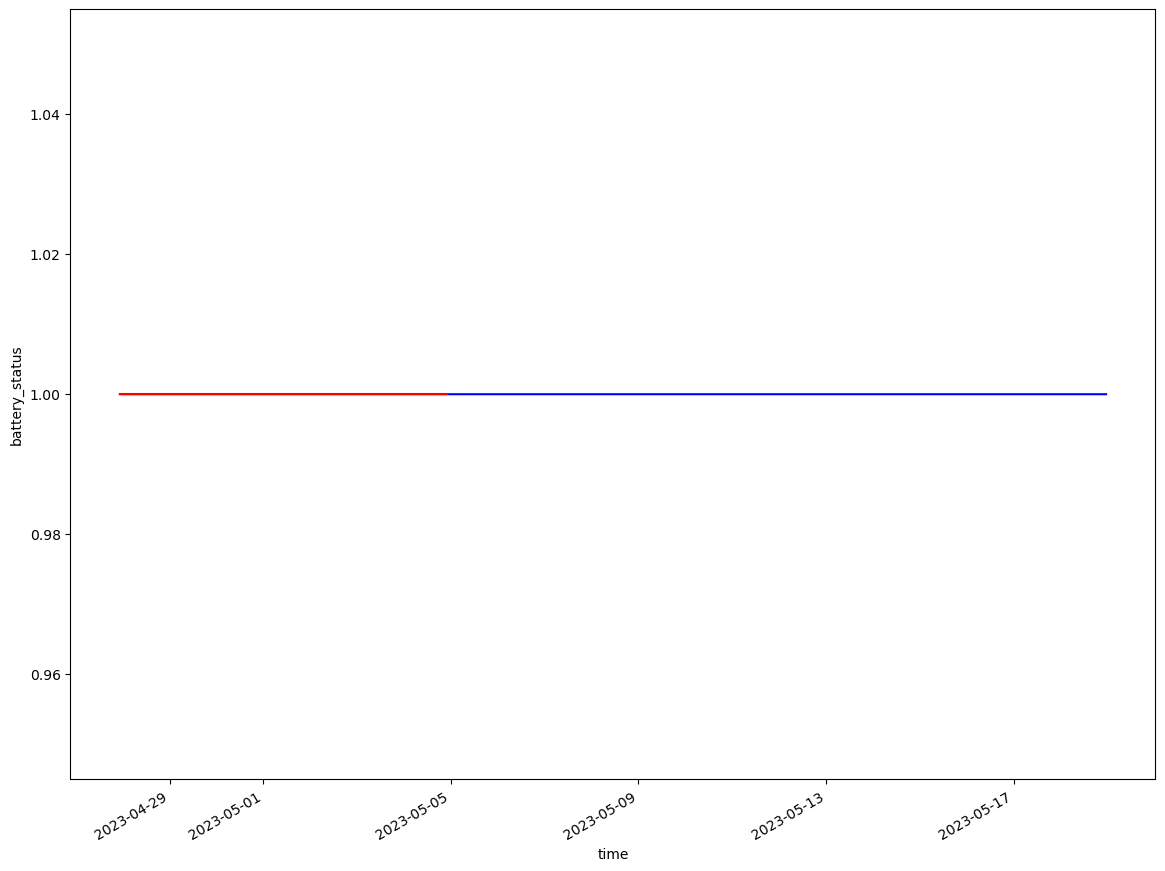

In [70]:
ds.BAT_STATUS.plot(figsize=(14,10), c='b')
ds05.BAT_STATUS.plot(c='r')

# --> well cut already in terms of battery (in this case)

# Flags:

# --> later